# Interaction-aware temporal transport notebook

This notebook compares **interaction-aware**, **geodesic**, and **Euclidean** couplings between consecutive timepoints.
The biological interpretation is centered on the **interaction-aware plan**, while Euclidean and geodesic serve as baselines.

## What this notebook is built to answer

For each transition between consecutive timepoints, we will:
- build three costs and three Sinkhorn plans,
- compare the plans at the cell and cell-type levels,
- quantify uncertainty, branching, convergence, and method disagreement,
- discuss where the interaction-aware plan adds biological information beyond Euclidean or geodesic matching.

In [2]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.spatial.distance import jensenshannon

import scanpy as sc
import torch

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

# import src from /Users/cweinrei/Documents/temporalGRN
import sys
sys.path.append("/Users/cweinrei/Documents/temporalGRN")
from src.models.iot.ot_utils import get_sinkhorn_plan, euclidean_cost, geodesic_cost
from src.models.iot.iot_parametrization import SimpleBilinear

# ---- user paths ----
path_adata = "/Users/cweinrei/Documents/temporalGRN/data/CAD/training_ready/test_case_CAD_04Mar.h5ad"
matrix_dir = "/Users/cweinrei/Documents/results_benchmark_sync/maestro/2026-03-05_14-07-07testcase/0"
pattern = "inferred_interaction_matrix_full_tp*.npy"

TIME_COL = "time"
CELLTYPE_COL = "Cluster_type"
EPSILON = 12.0
STORE_COSTS = False  # keep False unless you explicitly want the full cost matrices in memory

## Load the AnnData object and all consecutive transitions

The helper below loads the interaction matrices, maps `tp0..tp5` to the consecutive transitions in `adata.obs["time"]`, and extracts the matching source and target cell blocks.

In [3]:
def _to_numpy(X):
    """Convert sparse or dense arrays to a dense numpy array.
    Used before calling the OT cost and Sinkhorn functions."""
    return X.toarray() if sparse.issparse(X) else np.asarray(X)


def _tp_index(fp):
    """Extract the tp index from an interaction-matrix filename.
    Example: inferred_interaction_matrix_full_tp3.npy -> 3."""
    m = re.search(r"tp(\d+)", Path(fp).name)
    if m is None:
        raise ValueError(f"Could not parse transition index from {fp}")
    return int(m.group(1))


def load_transition_inputs(path_adata, matrix_dir, pattern=pattern, time_col=TIME_COL, celltype_col=CELLTYPE_COL):
    """Load the h5ad and interaction matrices, then align them to consecutive time transitions.
    Returns the AnnData object and one transition dict per consecutive pair of times."""
    adata = sc.read_h5ad(path_adata)
    times = np.sort(pd.to_numeric(adata.obs[time_col], errors="raise").unique())

    fps = sorted(Path(matrix_dir).glob(pattern), key=_tp_index)
    matrices = [np.load(fp) for fp in fps]

    if len(matrices) != len(times) - 1:
        raise ValueError(
            f"Loaded {len(matrices)} matrices but found {len(times)} timepoints -> expected {len(times)-1} transitions"
        )
    if matrices and matrices[0].shape[0] != adata.n_vars:
        raise ValueError(f"Matrix gene dimension {matrices[0].shape[0]} does not match adata.n_vars {adata.n_vars}")

    obs_time = pd.to_numeric(adata.obs[time_col], errors="raise").to_numpy()
    obs_type = adata.obs[celltype_col].astype(str).to_numpy()
    transitions = []

    for i, (t0, t1, A, fp) in enumerate(zip(times[:-1], times[1:], matrices, fps)):
        idx0 = np.where(obs_time == t0)[0]
        idx1 = np.where(obs_time == t1)[0]
        transitions.append({
            "name": f"{int(t0)}_to_{int(t1)}",
            "tp_index": i,
            "matrix_file": Path(fp).name,
            "source_time": float(t0),
            "target_time": float(t1),
            "idx0": idx0,
            "idx1": idx1,
            "cells0": adata.obs_names[idx0].to_numpy(),
            "cells1": adata.obs_names[idx1].to_numpy(),
            "labels0": obs_type[idx0],
            "labels1": obs_type[idx1],
            "x0": _to_numpy(adata.X[idx0]).astype(np.float32),
            "x1": _to_numpy(adata.X[idx1]).astype(np.float32),
            "interactions": A.astype(np.float32),
        })
    return adata, transitions


def transition_overview(transitions):
    """Summarize cell counts and cell-type counts for each transition.
    Helpful to check time alignment before computing any coupling."""
    rows = []
    for tr in transitions:
        rows.append({
            "transition": tr["name"],
            "matrix_file": tr["matrix_file"],
            "n_source": len(tr["idx0"]),
            "n_target": len(tr["idx1"]),
            "n_source_types": pd.Series(tr["labels0"]).nunique(),
            "n_target_types": pd.Series(tr["labels1"]).nunique(),
        })
    return pd.DataFrame(rows)

## Compute costs and couplings

For each transition we compute three costs and three plans:
- **InteractionAware** from the gene-by-gene interaction matrix,
- **Geodesic** as a geometry-aware baseline,
- **Euclidean** as the simplest baseline.

In [4]:
def _cost_summary(C):
    """Return a compact summary of one cost matrix.
    This keeps cost comparison lightweight and pairing-focused."""
    x = np.asarray(C, dtype=float).ravel()
    return {
        "min": float(np.min(x)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.median(x)),
        "q95": float(np.quantile(x, 0.95)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
    }


def compute_transition_plans(transitions, epsilon=EPSILON, keep_costs=STORE_COSTS):
    """Compute interaction-aware, geodesic, and Euclidean costs and Sinkhorn plans.
    Returns one result dict per transition, with plans and compact cost summaries."""
    bilinear = SimpleBilinear()
    results = []

    for tr in transitions:
        print(f"Processing transition {tr['name']} with matrix {tr['matrix_file']}...")
        X0 = torch.as_tensor(tr["x0"], dtype=torch.float32)
        X1 = torch.as_tensor(tr["x1"], dtype=torch.float32)
        A = torch.as_tensor(tr["interactions"], dtype=torch.float32)

        with torch.no_grad():
            print("  Computing costs...")
            C_A = bilinear(A, X0, X1)
            C_G = geodesic_cost(X0, X1)
            C_E = euclidean_cost(X0, X1)
            print("  Computing Sinkhorn plans...")
            P_A = get_sinkhorn_plan(X0, X1, C_A, epsilon=epsilon)
            P_G = get_sinkhorn_plan(X0, X1, C_G, epsilon=epsilon*np.median(C_G.cpu().numpy()))
            P_E = get_sinkhorn_plan(X0, X1, C_E, epsilon=epsilon*np.median(C_E.cpu().numpy()))  

        costs = {
            "InteractionAware": C_A.detach().cpu().numpy(),
            "Geodesic": C_G.detach().cpu().numpy(),
            "Euclidean": C_E.detach().cpu().numpy(),
        }
        plans = {
            "InteractionAware": P_A,
            "Geodesic": P_G,
            "Euclidean": P_E,
        }

        results.append({
            **{k: tr[k] for k in ["name", "tp_index", "matrix_file", "source_time", "target_time", "idx0", "idx1", "cells0", "cells1", "labels0", "labels1"]},
            "methods": {
                name: {
                    "plan": plans[name],
                    "cost": costs[name] if keep_costs else None,
                    "cost_summary": _cost_summary(costs[name]),
                }
                for name in costs
            },
        })
    return results


def cost_summary_table(results):
    """Stack all compact cost summaries into one table.
    Use this for a lightweight comparison of the three costs."""
    rows = []
    for res in results:
        for method, d in res["methods"].items():
            rows.append({"transition": res["name"], "method": method, **d["cost_summary"]})
    return pd.DataFrame(rows)


def plot_cost_summaries(results, metric="median"):
    """Plot one compact cost statistic across transitions for the three methods.
    This is intentionally small because the notebook is pairing-centered."""
    df = cost_summary_table(results)
    pivot = df.pivot(index="transition", columns="method", values=metric)
    ax = pivot.plot(kind="bar", figsize=(8, 4))
    ax.set_ylabel(metric)
    ax.set_title(f"Cost comparison: {metric}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



def prune_plan(P, top_k=None, min_frac=None, renormalize=True, eps=1e-12):
    """Keep only the strongest targets per source cell.
    Useful to make diffuse Sinkhorn plans more interpretable."""
    Q = np.asarray(P, dtype=float).copy()

    if top_k is not None:
        top_k = min(top_k, Q.shape[1])
        idx = np.argpartition(Q, -top_k, axis=1)[:, -top_k:]
        keep = np.zeros_like(Q, dtype=bool)
        np.put_along_axis(keep, idx, True, axis=1)
        Q[~keep] = 0.0

    if min_frac is not None:
        row_max = Q.max(axis=1, keepdims=True)
        Q[Q < min_frac * row_max] = 0.0

    if renormalize:
        Q = Q / (Q.sum(axis=1, keepdims=True) + eps)

    return Q

## Cell-level summaries from the plans

These helpers turn each row of a plan into biologically interpretable quantities:
- entropy and top-k mass,
- destination-type bias,
- dominant future cell type,
- agreement and disagreement between methods.

In [5]:
def _row_normalize(P, eps=1e-12):
    """Normalize each row of a coupling to sum to 1.
    This turns each row into a probability distribution over future cells."""
    P = np.asarray(P, dtype=float)
    return P / (P.sum(axis=1, keepdims=True) + eps)


def _row_entropy(Q, eps=1e-12):
    """Compute row entropy for a row-normalized plan.
    High entropy means a diffuse, uncertain future for the source cell."""
    return -(Q * np.log(Q + eps)).sum(axis=1)


def _topk_mass(Q, k=3):
    """Sum the top-k row probabilities.
    Higher values mean a sharper, more concentrated future assignment."""
    if k >= Q.shape[1]:
        return Q.sum(axis=1)
    idx = np.argpartition(Q, -k, axis=1)[:, -k:]
    return np.take_along_axis(Q, idx, axis=1).sum(axis=1)


def _row_type_distribution(Q, target_labels):
    """Aggregate each row of a plan by target cell type.
    Returns a row-normalized source-by-target-type table."""
    target_labels = pd.Series(target_labels).astype(str).to_numpy()
    target_types = pd.Index(pd.unique(target_labels))
    out = np.zeros((Q.shape[0], len(target_types)), dtype=float)
    for j, ct in enumerate(target_types):
        out[:, j] = Q[:, target_labels == ct].sum(axis=1)
    cols = [f"dest__{ct}" for ct in target_types]
    return pd.DataFrame(out, columns=cols), target_types


def build_cell_summary(result, method, top_k=None, min_frac=None):
    """Build per-source-cell summaries from a plan.
    top_k/min_frac can sharpen destination-type assignments."""
    P = np.asarray(result["methods"][method]["plan"], dtype=float)

    # full plan for entropy
    Q_full = _row_normalize(P)
    ent = _row_entropy(Q_full)

    # pruned plan for destination interpretation
    Q = prune_plan(P, top_k=top_k, min_frac=min_frac, renormalize=True) if (top_k is not None or min_frac is not None) else Q_full

    top1 = Q.max(axis=1)
    top3 = _topk_mass(Q, 3)
    top5 = _topk_mass(Q, 5)
    eff_n = 1.0 / np.maximum((Q ** 2).sum(axis=1), 1e-12)

    dest_df, target_types = _row_type_distribution(Q, result["labels1"])
    dom_idx = dest_df.to_numpy().argmax(axis=1)
    dom_type = target_types[dom_idx].astype(str)
    dom_mass = dest_df.to_numpy().max(axis=1)

    same_mass = np.array([
        dest_df.iloc[i][f"dest__{src}"] if f"dest__{src}" in dest_df.columns else 0.0
        for i, src in enumerate(pd.Series(result["labels0"]).astype(str))
    ])

    base = pd.DataFrame({
        "transition": result["name"],
        "source_time": result["source_time"],
        "target_time": result["target_time"],
        "method": method,
        "source_cell": result["cells0"],
        "source_type": pd.Series(result["labels0"]).astype(str).to_numpy(),
        "entropy": ent,  # from full plan
        "top1_mass": top1,
        "top3_mass": top3,
        "top5_mass": top5,
        "effective_n_targets": eff_n,
        "dominant_target_type": dom_type,
        "dominant_target_mass": dom_mass,
        "mass_to_same_type": same_mass,
    })
    return pd.concat([base, dest_df], axis=1)


def compare_methods_cellwise(result, method_a="InteractionAware", method_b="Euclidean"):
    """Compare two plans for the same transition at the source-cell level.
    Outputs entropy deltas, destination disagreement, and dominant-target changes."""
    A = build_cell_summary(result, method_a).set_index("source_cell")
    B = build_cell_summary(result, method_b).set_index("source_cell")

    dest_cols = [c for c in A.columns if c.startswith("dest__")]
    js = [
        float(jensenshannon(A.loc[cell, dest_cols].to_numpy(float), B.loc[cell, dest_cols].to_numpy(float), base=2.0))
        for cell in A.index
    ]

    out = pd.DataFrame({
        "transition": result["name"],
        "source_cell": A.index,
        "source_type": A["source_type"].values,
        f"entropy_{method_a}": A["entropy"].values,
        f"entropy_{method_b}": B["entropy"].values,
        "delta_entropy": A["entropy"].values - B["entropy"].values,
        f"top1_{method_a}": A["top1_mass"].values,
        f"top1_{method_b}": B["top1_mass"].values,
        "delta_top1": A["top1_mass"].values - B["top1_mass"].values,
        f"dominant_{method_a}": A["dominant_target_type"].values,
        f"dominant_{method_b}": B["dominant_target_type"].values,
        "same_dominant_target": A["dominant_target_type"].values == B["dominant_target_type"].values,
        "js_dest_type": js,
    })
    return out

## Cell-type transition matrices and Sankey plots

This is the main type-level view of each transition.
The difference heatmaps tell you where the interaction-aware plan changes the inferred flow relative to geodesic or Euclidean transport.

In [6]:
def type_transition_matrix(result, method, normalize=None, top_k=None, min_frac=None):
    """Aggregate a cell-cell plan into a source-type by target-type matrix.
    top_k / min_frac can prune each source-cell row before aggregation."""
    P = np.asarray(result["methods"][method]["plan"], dtype=float)

    if top_k is not None or min_frac is not None:
        P = prune_plan(P, top_k=top_k, min_frac=min_frac, renormalize=True)

    src = pd.Series(result["labels0"]).astype(str).to_numpy()
    tgt = pd.Series(result["labels1"]).astype(str).to_numpy()
    src_types = pd.Index(pd.unique(src))
    tgt_types = pd.Index(pd.unique(tgt))

    M = np.zeros((len(src_types), len(tgt_types)), dtype=float)
    for i, s in enumerate(src_types):
        rows = P[src == s].sum(axis=0)
        for j, t in enumerate(tgt_types):
            M[i, j] = rows[tgt == t].sum()

    T = pd.DataFrame(M, index=src_types, columns=tgt_types)

    if normalize == "row":
        T = T.div(T.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    return T


def plot_transition_heatmaps(
    result,
    normalize="row",
    top_k=5,
    min_frac=None,
    figsize=(14, 8),
):
    """Plot type-level transitions with aligned row/column labels so the diagonal means no type change."""
    methods = ["InteractionAware", "Geodesic", "Euclidean"]

    mats = {
        m: type_transition_matrix(
            result,
            m,
            normalize=normalize,
            top_k=top_k,
            min_frac=min_frac,
        )
        for m in methods
    }

    # common label order so diagonal = same source/target cell type
    # common_labels = sorted(
    #     set().union(*[set(M.index) | set(M.columns) for M in mats.values()])
    # )
    common_labels = ["SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"]

    mats = {
        m: mats[m].reindex(index=common_labels, columns=common_labels, fill_value=0.0)
        for m in methods
    }

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    vmax = max(float(M.values.max()) for M in mats.values())
    vmax = max(vmax, 1e-12)

    for ax, m in zip(axes[0], methods):
        M = mats[m]
        im = ax.imshow(M.values, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
        ax.set_title(f"{result['name']} — {m}")
        ax.set_xticks(range(len(common_labels)))
        ax.set_xticklabels(common_labels, rotation=90)
        ax.set_yticks(range(len(common_labels)))
        ax.set_yticklabels(common_labels)

        # draw diagonal guide
        ax.plot(
            [-0.5, len(common_labels) - 0.5],
            [-0.5, len(common_labels) - 0.5],
            linestyle="--",
            linewidth=1,
            alpha=0.5,
            color="white",
        )

    plt.colorbar(im, ax=axes[0].tolist(), shrink=0.8)

    diffs = {
        "InteractionAware - Geodesic": mats["InteractionAware"] - mats["Geodesic"],
        "InteractionAware - Euclidean": mats["InteractionAware"] - mats["Euclidean"],
    }

    vmax_diff = max(float(np.abs(D.values).max()) for D in diffs.values())
    vmax_diff = max(vmax_diff, 1e-8)

    for ax, (title, D) in zip(axes[1], diffs.items()):
        imd = ax.imshow(D.values, aspect="auto", cmap="coolwarm", vmin=-vmax_diff, vmax=vmax_diff)
        ax.set_title(title)
        ax.set_xticks(range(len(common_labels)))
        ax.set_xticklabels(common_labels, rotation=90)
        ax.set_yticks(range(len(common_labels)))
        ax.set_yticklabels(common_labels)

        ax.plot(
            [-0.5, len(common_labels) - 0.5],
            [-0.5, len(common_labels) - 0.5],
            linestyle="--",
            linewidth=1,
            alpha=0.5,
            color="black",
        )

    axes[1, 2].axis("off")
    plt.colorbar(imd, ax=axes[1, :2].tolist(), shrink=0.8)

    suffix = []
    if top_k is not None:
        suffix.append(f"top_k={top_k}")
    if min_frac is not None:
        suffix.append(f"min_frac={min_frac}")
    if suffix:
        fig.suptitle("Type-level transitions (" + ", ".join(suffix) + ")", y=1.02, fontsize=12)

    plt.show()

def plot_transition_sankey(
    result,
    method="InteractionAware",
    normalize="row",
    top_k=3,
    min_frac=None,
    min_mass=0.05,
):
    """Draw a cell-type Sankey from a pruned coupling.
    Using top_k makes diffuse plans biologically interpretable."""
    if not HAS_PLOTLY:
        raise ImportError("plotly is not available")

    T = type_transition_matrix(
        result,
        method,
        normalize=normalize,
        top_k=top_k,
        min_frac=min_frac,
    )

    src_nodes = [f"{int(result['source_time'])}: {x}" for x in T.index]
    tgt_nodes = [f"{int(result['target_time'])}: {x}" for x in T.columns]
    labels = src_nodes + tgt_nodes
    src_map = {x: i for i, x in enumerate(src_nodes)}
    tgt_map = {x: i + len(src_nodes) for i, x in enumerate(tgt_nodes)}

    source, target, value = [], [], []
    for i, s in enumerate(T.index):
        for j, t in enumerate(T.columns):
            v = float(T.iloc[i, j])
            if v >= min_mass:
                source.append(src_map[f"{int(result['source_time'])}: {s}"])
                target.append(tgt_map[f"{int(result['target_time'])}: {t}"])
                value.append(v)

    fig = go.Figure(go.Sankey(
        node=dict(label=labels, pad=18, thickness=16),
        link=dict(source=source, target=target, value=value),
    ))
    fig.update_layout(
        title_text=f"{result['name']} — {method} Sankey (top_k={top_k})",
        font_size=11,
    )
    fig.show()


## Embedding, uncertainty, and hidden heterogeneity

These helpers show where uncertain or method-sensitive source cells sit in cell space, and how destination bias varies across source cell types.

In [7]:
def _embedding_2d(adata, basis="X_umap"):
    """Return a 2D embedding from adata.obsm or compute PCA if needed.
    This is used only for visualization, not for the transport itself."""
    if basis in adata.obsm:
        emb = np.asarray(adata.obsm[basis])
        return emb[:, :2]
    if "X_pca" in adata.obsm and adata.obsm["X_pca"].shape[1] >= 2:
        emb = np.asarray(adata.obsm["X_pca"])
        return emb[:, :2]
    tmp = adata.copy()
    sc.pp.pca(tmp)
    return np.asarray(tmp.obsm["X_pca"])[:, :2]


def plot_source_metric(adata, result, df, value, basis="X_umap", cmap="viridis", figsize=(5, 4.5)):
    """Plot a source-cell metric on a 2D embedding for one transition.
    Useful for locating uncertainty, disagreement, or destination bias in cell space."""
    emb = _embedding_2d(adata, basis=basis)
    idx = result["idx0"]
    vals = df.set_index("source_cell").loc[result["cells0"], value].to_numpy()

    fig, ax = plt.subplots(figsize=figsize)
    sca = ax.scatter(emb[idx, 0], emb[idx, 1], c=vals, s=10, cmap=cmap)
    ax.set_title(f"{result['name']} — {value}")
    ax.set_xlabel(f"{basis}_1")
    ax.set_ylabel(f"{basis}_2")
    plt.colorbar(sca, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


def plot_entropy_by_celltype(cell_df, method="InteractionAware", figsize=(8, 4)):
    """Show row-entropy distributions by source cell type.
    This highlights stable versus plastic source populations."""
    d = cell_df[cell_df["method"] == method].copy().sort_values(["source_type", "entropy"])
    groups = [g["entropy"].to_numpy(float) for _, g in d.groupby("source_type", sort=False)]
    labels = [k for k, _ in d.groupby("source_type", sort=False)]

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_title(f"Entropy by source cell type — {method}")
    ax.set_ylabel("row entropy")
    ax.tick_params(axis="x", rotation=90)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_method_disagreement(compare_df, x, y, color="js_dest_type", figsize=(5.5, 5)):
    """Scatter two method-specific summaries and color by disagreement.
    This is useful for spotting cells where the interaction-aware plan changes the story."""
    fig, ax = plt.subplots(figsize=figsize)
    sca = ax.scatter(compare_df[x], compare_df[y], c=compare_df[color], s=10, cmap="magma")
    lo = min(compare_df[x].min(), compare_df[y].min())
    hi = max(compare_df[x].max(), compare_df[y].max())
    ax.plot([lo, hi], [lo, hi], "--", alpha=0.3)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")
    ax.grid(alpha=0.3)
    plt.colorbar(sca, ax=ax, shrink=0.8, label=color)
    plt.tight_layout()
    plt.show()


def plot_destination_bias(cell_df, method="InteractionAware", figsize=(9, 4.5)):
    """Plot average transported mass from each source type to each target type.
    This summarizes hidden destination bias inside the source populations."""
    d = cell_df[cell_df["method"] == method].copy()
    dest_cols = [c for c in d.columns if c.startswith("dest__")]
    avg = d.groupby("source_type")[dest_cols].mean()
    ax = avg.plot(kind="bar", stacked=True, figsize=figsize, colormap="tab20")
    ax.set_title(f"Average destination bias by source type — {method}")
    ax.set_ylabel("mean transported mass")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Convenience wrappers for ranking disagreement

These tables are useful for focusing the biological discussion on:
- high-uncertainty cells,
- source cell types with the strongest disagreement between methods,
- transitions where interaction-aware transport deviates most from Euclidean or geodesic baselines.

In [8]:
def build_all_cell_summaries(results):
    """Stack per-source-cell summaries across all transitions and methods.
    This table drives most cell-level exploratory analyses in the notebook."""
    dfs = []
    for res in results:
        for method in res["methods"]:
            dfs.append(build_cell_summary(res, method))
    return pd.concat(dfs, ignore_index=True)


def build_all_method_comparisons(results, method_a="InteractionAware", method_b="Euclidean"):
    """Stack source-cell comparisons between two methods across all transitions.
    Use this to rank high-disagreement cells and source types."""
    dfs = [compare_methods_cellwise(res, method_a=method_a, method_b=method_b) for res in results]
    return pd.concat(dfs, ignore_index=True)


def top_disagreement_cells(compare_df, score="js_dest_type", top_n=30):
    """Return the most method-sensitive source cells.
    These cells are often where interaction-aware transport adds the most biology."""
    return compare_df.sort_values(score, ascending=False).head(top_n).reset_index(drop=True)


def disagreement_by_celltype(compare_df, score="js_dest_type"):
    """Summarize disagreement scores by source cell type.
    This highlights which source populations depend most on the chosen cost."""
    return (
        compare_df.groupby("source_type", as_index=False)
        .agg(
            n_cells=("source_cell", "size"),
            mean_score=(score, "mean"),
            median_score=(score, "median"),
            frac_same_dominant=("same_dominant_target", "mean"),
        )
        .sort_values("mean_score", ascending=False)
        .reset_index(drop=True)
    )

## Run the analysis

Start by loading the data and computing the three couplings.

In [9]:
adata, transitions = load_transition_inputs(path_adata, matrix_dir, pattern=pattern)
transition_overview(transitions)

,transition,matrix_file,n_source,n_target,n_source_types,n_target_types
0,0_to_3,inferred_interaction_matrix_full_tp0.npy,4923,2583,6,5
1,3_to_5,inferred_interaction_matrix_full_tp1.npy,2583,10447,5,6
2,5_to_7,inferred_interaction_matrix_full_tp2.npy,10447,2541,6,6
3,7_to_9,inferred_interaction_matrix_full_tp3.npy,2541,3629,6,6
4,9_to_12,inferred_interaction_matrix_full_tp4.npy,3629,6273,6,6
5,12_to_16,inferred_interaction_matrix_full_tp5.npy,6273,17716,6,6


Processing transition 0_to_3 with matrix inferred_interaction_matrix_full_tp0.npy...
  Computing costs...


python(60472) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[auto_knn_k] k=2
shape evals (129,)
shape evecs (7506, 129)
evals: [3.59715242e-17 5.13026625e-02 8.16577210e-02 8.69597776e-02
 1.17334482e-01 1.20217225e-01 1.36257008e-01 1.50053044e-01
 1.57800556e-01 1.65118989e-01]
evecs: [[ 0.00783664 -0.01764188 -0.00186623 -0.00222408  0.00590024]
 [ 0.00764592  0.00575702  0.00358633 -0.00331371  0.0010762 ]
 [ 0.00789163 -0.01692279  0.0016189  -0.00414215  0.00457052]
 [ 0.00797207 -0.00987319 -0.0028522  -0.00035936  0.00252325]
 [ 0.00825627 -0.00234039 -0.00332122  0.00139255 -0.00022846]]
[heat_kernel] using n_eigs=94
[heat_kernel] tau=19.492, coeff[0:3]=[0.36787944 0.20358212 0.18359291], coeff[-3:]=[0.00104144 0.00102796 0.00099059]
  Computing Sinkhorn plans...
Processing transition 3_to_5 with matrix inferred_interaction_matrix_full_tp1.npy...
  Computing costs...
[auto_knn_k] k=2
shape evals (129,)
shape evecs (13030, 129)
evals: [7.12433132e-17 2.65765818e-02 3.18379436e-02 6.50140272e-02
 6.64787666e-02 8.54296075e-02 8.91538510e

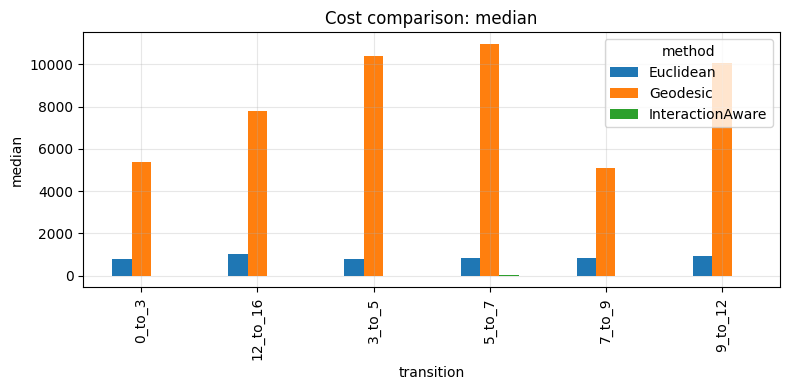

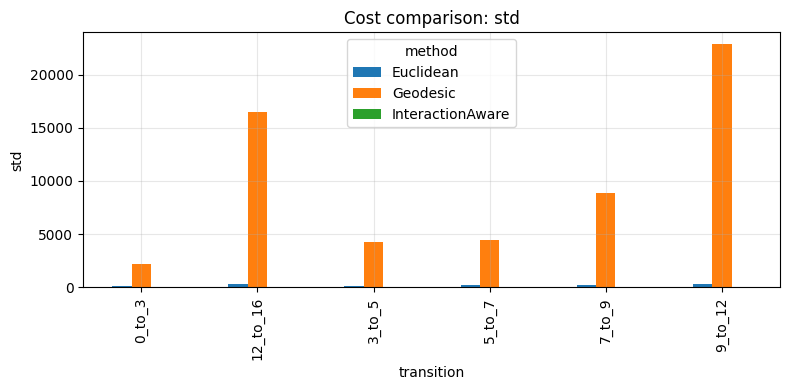

In [10]:
results = compute_transition_plans(transitions, epsilon=EPSILON, keep_costs=STORE_COSTS)
plot_cost_summaries(results, metric="median")
plot_cost_summaries(results, metric="std")

## Build summary tables

This creates the cell-level table used for entropy, destination bias, and disagreement analyses.

In [11]:
cell_df = build_all_cell_summaries(results)
comp_AE = build_all_method_comparisons(results, method_a="InteractionAware", method_b="Euclidean")
comp_AG = build_all_method_comparisons(results, method_a="InteractionAware", method_b="Geodesic")

cell_df.head()

,transition,source_time,target_time,method,source_cell,source_type,entropy,top1_mass,top3_mass,top5_mass,effective_n_targets,dominant_target_type,dominant_target_mass,mass_to_same_type,dest__SMC-1,dest__SMC-2,dest__SMC-3,dest__FMC-1,dest__FMC-2,dest__CMC
0,0_to_3,0.0,3.0,InteractionAware,AAACCCAAGCCGTCGT-1_1,SMC-2,7.856484,0.000406,0.001216,0.002025,2581.847604,SMC-1,0.517271,0.260251,0.517271,0.260251,0.197227,0.022909,0.002341,NaN
1,0_to_3,0.0,3.0,InteractionAware,AAACCCACAGCCCAGT-1_1,SMC-1,7.856622,0.000398,0.001194,0.001989,2582.560426,SMC-1,0.525956,0.525956,0.525956,0.249866,0.199012,0.022856,0.002311,NaN
2,0_to_3,0.0,3.0,InteractionAware,AAACCCAGTGATATAG-1_1,SMC-3,7.856507,0.000408,0.001222,0.002036,2581.963943,SMC-1,0.516726,0.198922,0.516726,0.259021,0.198922,0.022993,0.002339,NaN
3,0_to_3,0.0,3.0,InteractionAware,AAACCCATCCACTTCG-1_1,SMC-2,7.856372,0.000411,0.001229,0.002046,2581.265713,SMC-1,0.516023,0.261647,0.516023,0.261647,0.197009,0.022968,0.002354,NaN
4,0_to_3,0.0,3.0,InteractionAware,AAACGAAGTATATGGA-1_1,SMC-2,7.856498,0.000404,0.001212,0.002019,2581.919505,SMC-1,0.519246,0.260428,0.519246,0.260428,0.195212,0.022775,0.002338,NaN


In [12]:
comp_AE.head()

,transition,source_cell,source_type,entropy_InteractionAware,entropy_Euclidean,delta_entropy,top1_InteractionAware,top1_Euclidean,delta_top1,dominant_InteractionAware,dominant_Euclidean,same_dominant_target,js_dest_type
0,0_to_3,AAACCCAAGCCGTCGT-1_1,SMC-2,7.856484,7.856698,-0.000214,0.000406,0.000392,0.000014,SMC-1,SMC-1,True,0.005367
1,0_to_3,AAACCCACAGCCCAGT-1_1,SMC-1,7.856622,7.856698,-0.000076,0.000398,0.000394,0.000005,SMC-1,SMC-1,True,0.003059
2,0_to_3,AAACCCAGTGATATAG-1_1,SMC-3,7.856507,7.856698,-0.000192,0.000408,0.000392,0.000015,SMC-1,SMC-1,True,0.005048
3,0_to_3,AAACCCATCCACTTCG-1_1,SMC-2,7.856372,7.856692,-0.000321,0.000411,0.000393,0.000018,SMC-1,SMC-1,True,0.006494
4,0_to_3,AAACGAAGTATATGGA-1_1,SMC-2,7.856498,7.856694,-0.000196,0.000404,0.000392,0.000012,SMC-1,SMC-1,True,0.004929


## Inspect one transition in detail

The interaction-aware biology is often easiest to see transition by transition.
A good first pass is to inspect:
- the three type-level transition heatmaps,
- the interaction-aware Sankey,
- entropy and disagreement on the source cells.

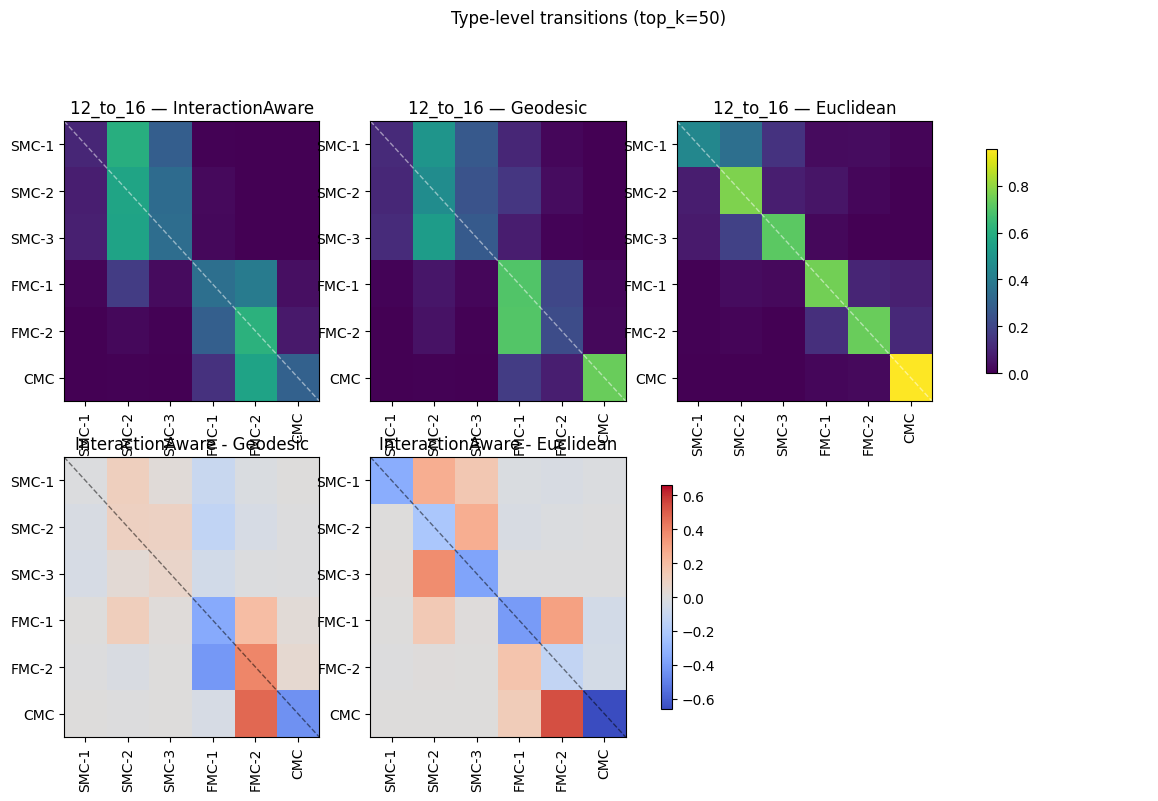

In [17]:
res = results[5]  # change index to inspect other transitions
plot_transition_heatmaps(res, normalize="row",top_k=50)

In [84]:
if HAS_PLOTLY:
    plot_transition_sankey(results[0], method="Euclidean", normalize=None, min_mass=0.0,top_k=50)

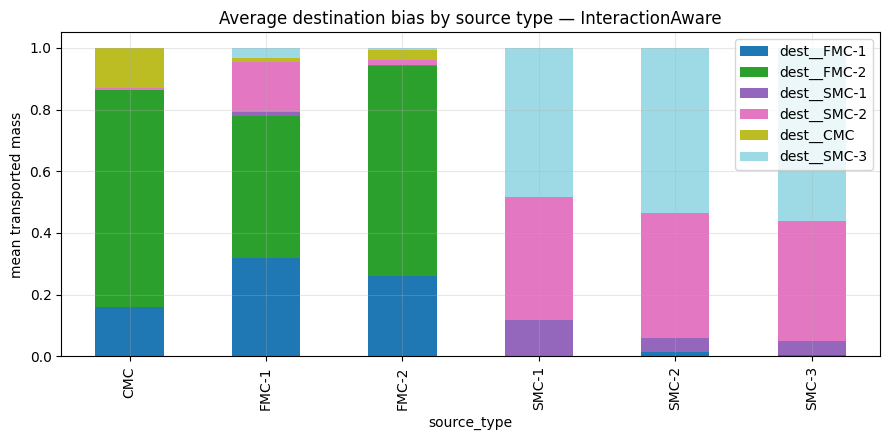

In [104]:
cell_A = build_cell_summary(res, "InteractionAware",top_k=5)
# comp = compare_methods_cellwise(res, method_a="InteractionAware", method_b="Euclidean")

# plot_entropy_by_celltype(cell_df[cell_df["transition"] == res["name"]], method="InteractionAware")
# plot_method_disagreement(comp, x="entropy_InteractionAware", y="entropy_Euclidean", color="js_dest_type")
# plot_source_metric(adata, res, comp, value="js_dest_type")
plot_destination_bias(cell_A[cell_A["transition"] == res["name"]], method="InteractionAware")

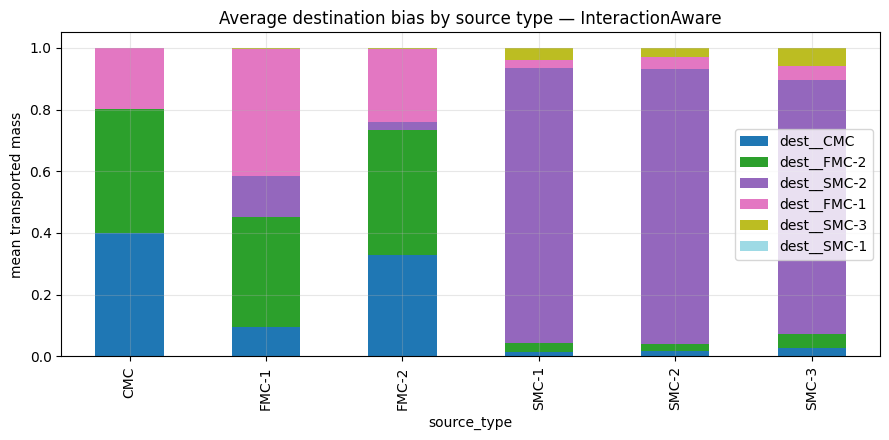

In [111]:
res = results[4]
cell_A = build_cell_summary(res, "InteractionAware",top_k=5)
plot_destination_bias(cell_A[cell_A["transition"] == res["name"]], method="InteractionAware")

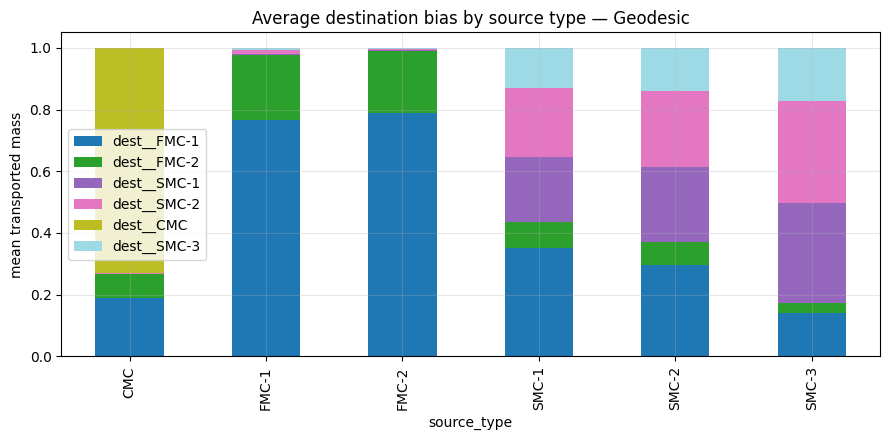

In [103]:
cell_euclid = build_cell_summary(res, "Geodesic",top_k=5)
plot_destination_bias(cell_euclid[cell_euclid["transition"] == res["name"]], method="Geodesic")

In [18]:
import numpy as np
import plotly.graph_objects as go


def plot_multitime_sankey_strict(
    results,
    method="InteractionAware",
    common_labels=("SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"),
    normalize=False,
    top_k=3,
    min_frac=None,
    min_mass=0.03,
    min_frac_source=0.10,
    top_links_per_source=2,
    node_thickness=16,
    height=800,
    width=1400,
):
    """Plot a filtered multi-timepoint Sankey with fixed positions and colors.
    Keeps only strong source-type flows and drops inactive nodes entirely."""
    if not HAS_PLOTLY:
        raise ImportError("plotly is not available")

    color_map = {
        "SMC-1": "#1f77b4",
        "SMC-2": "#ff7f0e",
        "SMC-3": "#2ca02c",
        "FMC-1": "#d62728",
        "FMC-2": "#9467bd",
        "CMC":   "#8c564b",
    }

    def hex_to_rgba(h, alpha=0.45):
        h = h.lstrip("#")
        r, g, b = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
        return f"rgba({r},{g},{b},{alpha})"

    results = sorted(results, key=lambda r: (r["source_time"], r["target_time"]))
    times = sorted(set([r["source_time"] for r in results] + [r["target_time"] for r in results]))

    # Collect filtered edges first
    edges = []

    for res in results:
        T = type_transition_matrix(
            res,
            method,
            normalize=normalize,
            top_k=top_k,
            min_frac=min_frac,
        ).reindex(index=common_labels, columns=common_labels, fill_value=0.0)

        for src_ct in common_labels:
            row = T.loc[src_ct].copy()
            row_sum = float(row.sum())
            if row_sum <= 0:
                continue

            # keep only links that are both absolutely and relatively meaningful
            thr = max(min_mass, min_frac_source * row_sum)
            row = row[row >= thr]

            if len(row) == 0:
                continue

            row = row.sort_values(ascending=False).head(top_links_per_source)

            for tgt_ct, val in row.items():
                edges.append({
                    "source_time": res["source_time"],
                    "target_time": res["target_time"],
                    "source_type": src_ct,
                    "target_type": tgt_ct,
                    "value": float(val),
                })

    if len(edges) == 0:
        raise ValueError("No links left after filtering; decrease min_mass or min_frac_source.")

    # Keep only active nodes
    active_nodes = set()
    for e in edges:
        active_nodes.add((e["source_time"], e["source_type"]))
        active_nodes.add((e["target_time"], e["target_type"]))

    # Fixed positions by time and cell-type order
    n_times = max(len(times) - 1, 1)
    n_types = len(common_labels)

    node_labels = []
    node_colors = []
    node_x = []
    node_y = []
    node_map = {}

    for i, t in enumerate(times):
        for j, ct in enumerate(common_labels):
            key = (t, ct)
            if key not in active_nodes:
                continue

            node_map[key] = len(node_labels)
            node_labels.append(f"{int(t)}: {ct}")
            node_colors.append(color_map.get(ct, "#999999"))

            # fixed time position
            node_x.append(i / n_times)

            # fixed vertical slot by common_labels order
            # leave margins so labels don't touch the border
            node_y.append((j + 0.5) / (n_types + 0.5))

    source, target, value, link_color, link_label = [], [], [], [], []

    for e in edges:
        s_key = (e["source_time"], e["source_type"])
        t_key = (e["target_time"], e["target_type"])
        source.append(node_map[s_key])
        target.append(node_map[t_key])
        value.append(e["value"])
        link_color.append(hex_to_rgba(color_map.get(e["source_type"], "#999999"), alpha=0.40))
        link_label.append(
            f"{int(e['source_time'])}→{int(e['target_time'])}: "
            f"{e['source_type']} → {e['target_type']} ({e['value']:.3f})"
        )

    fig = go.Figure(go.Sankey(
        arrangement="fixed",
        node=dict(
            label=node_labels,
            color=node_colors,
            x=node_x,
            y=node_y,
            pad=18,
            thickness=node_thickness,
            line=dict(color="black", width=0.4),
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_color,
            label=link_label,
        ),
    ))

    fig.update_layout(
        title_text=(
            f"Cell-type flows across time — {method} "
            f"(top_k={top_k}, top_links/source={top_links_per_source})"
        ),
        font_size=11,
        width=width,
        height=height,
    )
    fig.show()

In [174]:
plot_multitime_sankey_strict(
    results,
    method="InteractionAware",
    common_labels=["SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"],
    normalize=False,
    top_k=100,
    min_mass=0.0,
    min_frac_source=0.00,
    top_links_per_source=2,
    height=650,
    width=1200,
)

In [19]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_transition_bars(
    results,
    method="InteractionAware",
    common_labels=("SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"),
    normalize=False,
    top_k=3,
    min_frac=None,
    min_display=0.03,
    top_targets_per_source=None,
    ncols=3,
    figsize_per_panel=(4.8, 4.0),
):
    """Plot one stacked-bar panel per transition.
    Bars are source types, colors are target types, with fixed order and colors."""
    color_map = {
        "SMC-1": "#1f77b4",
        "SMC-2": "#ff7f0e",
        "SMC-3": "#2ca02c",
        "FMC-1": "#d62728",
        "FMC-2": "#9467bd",
        "CMC":   "#8c564b",
    }

    results = sorted(results, key=lambda r: (r["source_time"], r["target_time"]))
    n = len(results)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
        sharey=normalize,
    )

    x = np.arange(len(common_labels))

    for ax, res in zip(axes.flat, results):
        T = type_transition_matrix(
            res,
            method,
            normalize="row" if normalize else None,
            top_k=top_k,
            min_frac=min_frac,
        ).reindex(index=common_labels, columns=common_labels, fill_value=0.0)

        # Optional simplification: keep only top few target types per source
        if top_targets_per_source is not None:
            T2 = T.copy()
            for s in common_labels:
                row = T2.loc[s]
                keep = row.sort_values(ascending=False).head(top_targets_per_source).index
                T2.loc[s, ~T2.columns.isin(keep)] = 0.0
            if normalize:
                T2 = T2.div(T2.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
            T = T2

        # Remove tiny segments for display
        T = T.mask(T < min_display, 0.0)
        if normalize:
            T = T.div(T.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)

        bottom = np.zeros(len(common_labels), dtype=float)
        for tgt in common_labels:
            vals = T[tgt].to_numpy(dtype=float)
            ax.bar(
                x,
                vals,
                bottom=bottom,
                color=color_map[tgt],
                edgecolor="white",
                linewidth=0.5,
                width=0.8,
                label=tgt,
            )
            bottom += vals

        ax.set_title(f"{int(res['source_time'])} → {int(res['target_time'])}")
        ax.set_xticks(x)
        ax.set_xticklabels(common_labels, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.3)

        if normalize:
            ax.set_ylim(0, 1.0)
            ax.set_ylabel("fraction of outgoing mass")
        else:
            ax.set_ylabel("outgoing transported mass")

    for ax in axes.flat[n:]:
        ax.axis("off")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(common_labels), loc="upper center", frameon=False)

    plt.show()

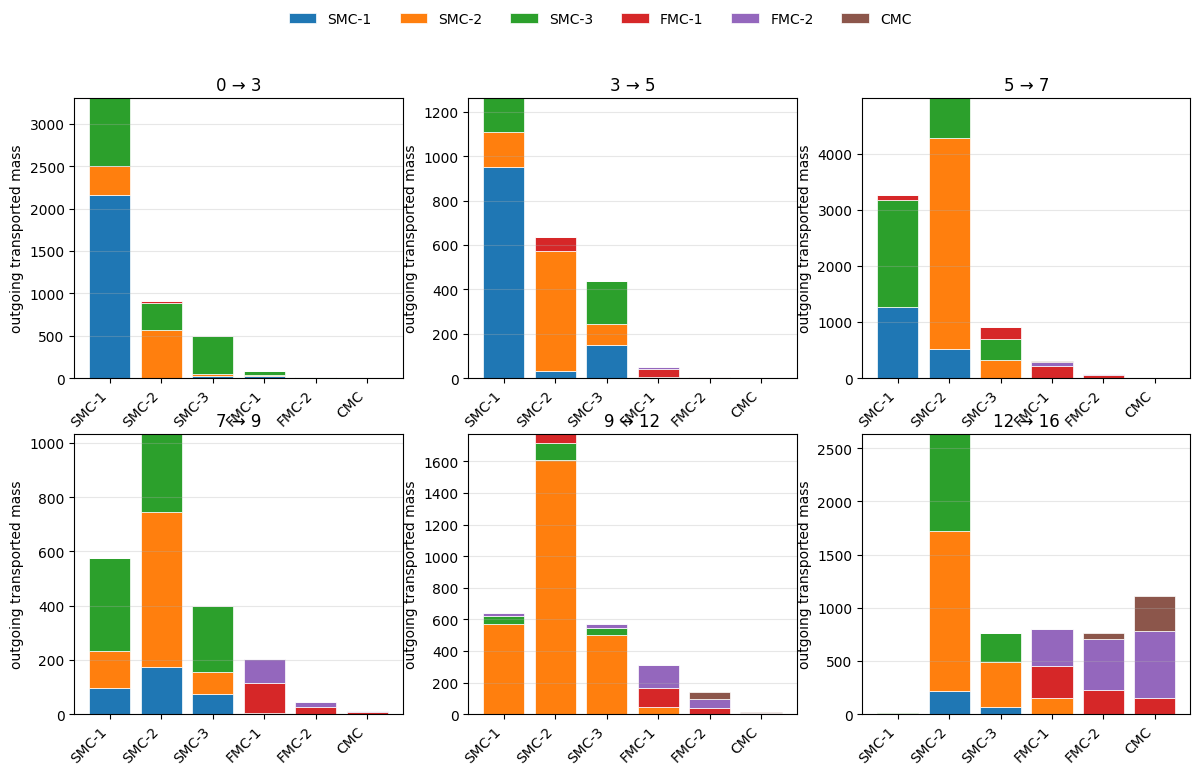

In [20]:
plot_transition_bars(
    results,
    method="InteractionAware",
    common_labels=["SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"],
    normalize=False,
    top_k=50,
    min_display=0.0,
    top_targets_per_source=3,
)

In [21]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go


# ---------------------------------------------------------------------------
# Colour palette
# ---------------------------------------------------------------------------
COLOR_MAP = {
    "SMC-1": "#1f77b4",
    "SMC-2": "#ff7f0e",
    "SMC-3": "#2ca02c",
    "FMC-1": "#d62728",
    "FMC-2": "#9467bd",
    "CMC":   "#8c564b",
}
DEFAULT_RANK = {ct: i for i, ct in enumerate(COLOR_MAP)}


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def _hex_to_rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgba(h, a=0.30):
    r, g, b = _hex_to_rgb(h)
    return f"rgba({r},{g},{b},{a})"


def _blend(h1, h2, a=0.30):
    r1, g1, b1 = _hex_to_rgb(h1)
    r2, g2, b2 = _hex_to_rgb(h2)
    return f"rgba({(r1+r2)//2},{(g1+g2)//2},{(b1+b2)//2},{a})"


# ---------------------------------------------------------------------------
# Main function
# ---------------------------------------------------------------------------
def plot_multitime_sankey_clean(
    results,
    method="InteractionAware",
    common_labels=("SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"),
    normalize=False,
    top_k=3,
    min_frac=None,
    # ---- pull-based filtering ----
    top_ancestors=3,           # for each destination node, keep its top-N source nodes
    min_link_frac=0.08,        # ancestor link must carry at least this fraction of the
                               # destination node's total inflow to be kept
    min_abs_value=0.03,        # hard floor on absolute link value regardless of fractions
    # ---- layout ----
    link_color_mode="source",  # "neutral" | "source" | "target" | "blend"
    node_thickness=20,
    node_pad=30,
    min_y_gap=0.11,            # minimum vertical separation between node centres
    height=800,
    width=None,
    show=False,
):
    common_labels = list(common_labels)

    # ------------------------------------------------------------------
    # 1. Build the full edge table from all transition matrices
    # ------------------------------------------------------------------
    results = sorted(results, key=lambda r: (r["source_time"], r["target_time"]))
    times   = sorted(
        {r["source_time"] for r in results} | {r["target_time"] for r in results}
    )

    all_edges = []
    for res in results:
        T = (
            type_transition_matrix(res, method, normalize=normalize,
                                   top_k=top_k, min_frac=min_frac)
            .reindex(index=common_labels, columns=common_labels, fill_value=0.0)
        )
        for src in common_labels:
            for tgt in common_labels:
                val = float(T.loc[src, tgt])
                if val > 0:
                    all_edges.append(dict(
                        source_time=res["source_time"],
                        target_time=res["target_time"],
                        source_type=src,
                        target_type=tgt,
                        value=val,
                    ))

    if not all_edges:
        raise ValueError("Transition matrices are all zero.")

    full_edges = pd.DataFrame(all_edges)

    # ------------------------------------------------------------------
    # 2. PULL PASS — work right-to-left
    #
    #    At the last time step, every cell type with any inflow is a
    #    valid destination.  For each destination node we keep only its
    #    top `top_ancestors` source nodes whose link carries at least
    #    `min_link_frac` of that destination's total inflow.
    #    Only source nodes selected here are allowed at the previous
    #    time step, and we repeat leftward.
    # ------------------------------------------------------------------

    # Nodes confirmed to be visible: set of (time, cell_type)
    allowed: set[tuple] = set()

    # Edges that survive the pull pass
    kept_edge_rows = []

    # Seed: at the last time point, admit every cell type that receives
    # any flow at all (the full final population).
    last_t = times[-1]
    last_inflow = full_edges[full_edges["target_time"] == last_t]
    final_nodes = set(last_inflow["target_type"].unique())
    # Also include any cell type at the last time that sends flow
    # (shouldn't happen, but guards edge cases)
    for ct in final_nodes:
        allowed.add((last_t, ct))

    # Walk backward through consecutive time-step pairs
    time_pairs = list(zip(times[:-1], times[1:]))  # (t0,t1), (t1,t2), ...
    for src_t, tgt_t in reversed(time_pairs):

        # Candidate edges for this time pair
        pair_edges = full_edges[
            (full_edges["source_time"] == src_t) &
            (full_edges["target_time"] == tgt_t)
        ]

        # For each destination node that is already allowed at tgt_t,
        # find its best ancestors at src_t
        selected_sources: set[str] = set()

        for tgt_ct in [ct for (t, ct) in allowed if t == tgt_t]:
            incoming = pair_edges[pair_edges["target_type"] == tgt_ct]
            if incoming.empty:
                continue

            total_in = float(incoming["value"].sum())
            threshold = max(min_link_frac * total_in, min_abs_value)

            top = (
                incoming[incoming["value"] >= threshold]
                .sort_values("value", ascending=False)
                .head(top_ancestors)
            )

            for row in top.itertuples(index=False):
                selected_sources.add(row.source_type)
                allowed.add((src_t, row.source_type))
                kept_edge_rows.append(dict(
                    source_time=src_t,
                    target_time=tgt_t,
                    source_type=row.source_type,
                    target_type=tgt_ct,
                    value=row.value,
                ))

    if not kept_edge_rows:
        raise ValueError("No edges survived the pull pass — lower min_link_frac or min_abs_value.")

    edges = pd.DataFrame(kept_edge_rows)

    # ------------------------------------------------------------------
    # 3. Recompute active nodes per time step from surviving edges
    # ------------------------------------------------------------------
    active_by_time = {t: set() for t in times}
    for r in edges.itertuples(index=False):
        active_by_time[r.source_time].add(r.source_type)
        active_by_time[r.target_time].add(r.target_type)

    times = [t for t in times if active_by_time[t]]

    # ------------------------------------------------------------------
    # 4. Y-layout: barycentric from RIGHT to LEFT
    #    (mirrors the pull logic — anchor positions at the last column,
    #     then pull each column's positions toward its downstream neighbours)
    # ------------------------------------------------------------------
    Y_LO, Y_HI = 0.05, 0.95

    y_pos     = {}  # (time, cell_type) → y in [0,1]
    order_map = {}  # time → ordered list of cell types

    def _enforce_gap(ys_list, lo=Y_LO, hi=Y_HI, min_gap=min_y_gap):
        """Push nodes apart until no two are closer than min_gap, then clamp."""
        ys = list(ys_list)
        for _ in range(200):
            changed = False
            for k in range(len(ys) - 1):
                if ys[k + 1] - ys[k] < min_gap:
                    mid = (ys[k] + ys[k + 1]) / 2
                    ys[k]     = mid - min_gap / 2
                    ys[k + 1] = mid + min_gap / 2
                    changed = True
            if not changed:
                break
        # rescale to fit [lo, hi] if nodes were pushed out of range
        span = max(ys) - min(ys)
        avail = hi - lo
        if span > avail:
            scale = avail / span
            mid   = (max(ys) + min(ys)) / 2
            ys = [0.5 + (y - mid) * scale for y in ys]
        else:
            shift = 0
            if min(ys) < lo:
                shift = lo - min(ys)
            elif max(ys) > hi:
                shift = hi - max(ys)
            ys = [y + shift for y in ys]
        return ys

    # Seed the last column with a simple default rank order
    last_active = sorted(active_by_time[times[-1]], key=lambda ct: DEFAULT_RANK[ct])
    order_map[times[-1]] = last_active
    n = len(last_active)
    seed_ys = list(np.linspace(Y_LO, Y_HI, n)) if n > 1 else [0.5]
    seed_ys = _enforce_gap(seed_ys)
    for ct, y in zip(last_active, seed_ys):
        y_pos[(times[-1], ct)] = float(y)

    # Walk left: each column's y is the weighted average of its
    # *downstream* neighbours (the pull equivalent of barycentric sort)
    for t in reversed(times[:-1]):
        active   = list(active_by_time[t])
        outgoing = edges[edges["source_time"] == t]

        scores = []
        for ct in active:
            out = outgoing[outgoing["source_type"] == ct]
            if len(out):
                bary = np.average(
                    [y_pos[(r.target_time, r.target_type)]
                     for r in out.itertuples(index=False)],
                    weights=out["value"].to_numpy(),
                )
            else:
                bary = DEFAULT_RANK[ct] / max(len(common_labels) - 1, 1)
            scores.append((bary, DEFAULT_RANK[ct], ct))

        ordered = [ct for _, _, ct in sorted(scores)]
        order_map[t] = ordered

        raw_ys = []
        for ct in ordered:
            out_ct = edges[(edges["source_time"] == t) & (edges["source_type"] == ct)]
            if not out_ct.empty:
                bary = float(np.average(
                    [y_pos[(r.target_time, r.target_type)] for r in out_ct.itertuples(index=False)],
                    weights=out_ct["value"].to_numpy(),
                ))
            else:
                bary = DEFAULT_RANK[ct] / max(len(common_labels) - 1, 1)
            raw_ys.append(bary)

        final_ys = _enforce_gap(raw_ys)
        for ct, y in zip(ordered, final_ys):
            y_pos[(t, ct)] = float(y)

    # ------------------------------------------------------------------
    # 5. Build Sankey nodes
    # ------------------------------------------------------------------
    node_map    = {}
    node_labels = []
    node_colors = []
    node_x      = []
    node_y      = []

    n_gaps = max(len(times) - 1, 1)
    for i, t in enumerate(times):
        x = 0.02 + 0.96 * (i / n_gaps)
        for ct in order_map.get(t, []):
            node_map[(t, ct)] = len(node_labels)
            node_labels.append(f"{int(t)}: {ct}")
            node_colors.append(COLOR_MAP[ct])
            node_x.append(round(x, 4))
            node_y.append(round(y_pos[(t, ct)], 4))

    # ------------------------------------------------------------------
    # 6. Build Sankey links
    # ------------------------------------------------------------------
    link_sources, link_targets, link_values = [], [], []
    link_colors_list, link_hovers           = [], []

    for r in edges.itertuples(index=False):
        sk = (r.source_time, r.source_type)
        tk = (r.target_time, r.target_type)
        if sk not in node_map or tk not in node_map:
            continue

        link_sources.append(node_map[sk])
        link_targets.append(node_map[tk])
        link_values.append(r.value)

        sc = COLOR_MAP[r.source_type]
        tc = COLOR_MAP[r.target_type]
        if link_color_mode == "source":
            lc = _rgba(sc, 0.32)
        elif link_color_mode == "target":
            lc = _rgba(tc, 0.32)
        elif link_color_mode == "blend":
            lc = _blend(sc, tc, 0.32)
        else:
            lc = "rgba(150,150,150,0.20)"

        link_colors_list.append(lc)
        link_hovers.append(
            f"{int(r.source_time)} → {int(r.target_time)}<br>"
            f"{r.source_type} → {r.target_type}<br>"
            f"value = {r.value:.3f}"
        )

    # ------------------------------------------------------------------
    # 7. Figure
    # ------------------------------------------------------------------
    fig = go.Figure(
        go.Sankey(
            arrangement="fixed",
            node=dict(
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y,
                pad=node_pad,
                thickness=node_thickness,
                line=dict(color="rgba(0,0,0,0.25)", width=0.5),
                hovertemplate="%{label}<extra></extra>",
            ),
            link=dict(
                source=link_sources,
                target=link_targets,
                value=link_values,
                color=link_colors_list,
                customdata=link_hovers,
                hovertemplate="%{customdata}<extra></extra>",
            ),
        )
    )

    fig.update_layout(
        title=dict(
            text=f"Cell-type flows across time — {method}",
            font=dict(size=15),
        ),
        autosize=(width is None),
        width=width,
        height=height,
        font=dict(size=12),
        margin=dict(l=90, r=90, t=80, b=60),
    )

    if show:
        fig.show(config={"responsive": True})

    return fig

In [25]:
plot_multitime_sankey_clean(
    results,
    method="InteractionAware",
    common_labels=["SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"],
    normalize=False,
    top_k=1000,
    min_frac=None,
    top_ancestors=3,
    min_link_frac=0.1,
    min_abs_value=0.2,
    link_color_mode="source",
    node_thickness=20,
    node_pad=30,
    min_y_gap=0.11,
    height=800,
    width=None,
    show=False,
)

In [ ]:
# hard to interpret because we have all cell types everywhere it's not classical differenciation

In [227]:
import pickle

to_save = {
    "results": results,
}

with open("transition_outputs.pkl", "wb") as f:
    pickle.dump(to_save, f)

In [40]:
plot_multitime_sankey_clean(
    results,
    method="InteractionAware",
    common_labels=["SMC-1", "SMC-2", "SMC-3", "FMC-1", "FMC-2", "CMC"],
    normalize=False,
    top_k=10,
    min_frac=None,
    top_ancestors=2,
    min_link_frac=0.00,
    min_abs_value=0.00,
    link_color_mode="source",
    node_thickness=20,
    node_pad=30,
    min_y_gap=0.11,
    height=800,
    width=None,
    show=False,
)